## Exploratory Data Analysis

In this notebook, I explore the cleaned fake news dataset to better understand its structure and the characteristics of the text data.

The main goals are:
- check the distribution of fake and real news
- analyze article length
- inspect some common patterns in the text

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## Load the Cleaned Dataset

In [2]:
df = pd.read_csv("../data/clean_data.csv")

## Check the Dataset

In [3]:
df.head()

,title,text,label,content,content_clean
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",FAKE,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley has had enough ...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,FAKE,Failed GOP Candidates Remembered In Hilarious...,failed gop candidates remembered in hilarious ...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,FAKE,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pence’s new dc neighbors are hilariously ...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,REAL,California AG pledges to defend birth control ...,california ag pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,FAKE,AZ RANCHERS Living On US-Mexico Border Destroy...,az ranchers living on usmexico border destroy ...


In [4]:
df.shape

(39105, 5)

In [5]:
df.columns

Index(['title', 'text', 'label', 'content', 'content_clean'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39105 entries, 0 to 39104
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          39105 non-null  object
 1   text           39105 non-null  object
 2   label          39105 non-null  object
 3   content        39105 non-null  object
 4   content_clean  39100 non-null  object
dtypes: object(5)
memory usage: 1.5+ MB


In [7]:
df.isnull().sum()

title            0
text             0
label            0
content          0
content_clean    5
dtype: int64

In [8]:
df = df.dropna()

## Label Distribution

I first check how many real and fake articles are present in the dataset.

This helps me understand whether the dataset is balanced.

In [9]:
df["label"].value_counts()

label
REAL    21197
FAKE    17903
Name: count, dtype: int64

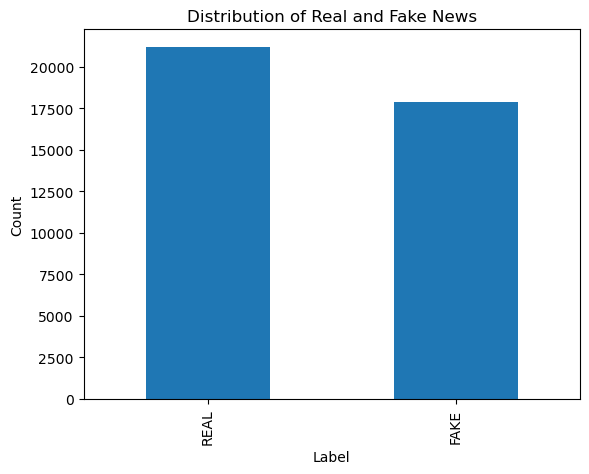

In [10]:
df["label"].value_counts().plot(kind="bar")
plt.title("Distribution of Real and Fake News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Percentage of each class

In [11]:
label_percentages = df["label"].value_counts(normalize=True) * 100
print(label_percentages)

label
REAL    54.212276
FAKE    45.787724
Name: proportion, dtype: float64


## Text Length Analysis

Here I analyze the length of the articles to better understand the text data.

I create a few simple features:
- character count
- word count

In [12]:
df["char_count"] = df["content_clean"].apply(len)
df["word_count"] = df["content_clean"].apply(lambda x: len(x.split()))

In [13]:
df[["content_clean", "char_count", "word_count"]].head()

,content_clean,char_count,word_count
0,breaking gop chairman grassley has had enough ...,2121,370
1,failed gop candidates remembered in hilarious ...,2766,500
2,mike pence’s new dc neighbors are hilariously ...,2310,385
3,california ag pledges to defend birth control ...,680,96
4,az ranchers living on usmexico border destroy ...,892,155


## General statistics for text length

In [14]:
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,39100.000000,39100.000000
mean,2409.538849,403.866061
std,1866.265173,310.301487
min,8.000000,1.000000
25%,1290.000000,215.000000
50%,2205.000000,372.000000
75%,3039.000000,514.000000
max,50109.000000,8042.000000


## Histogram of character count

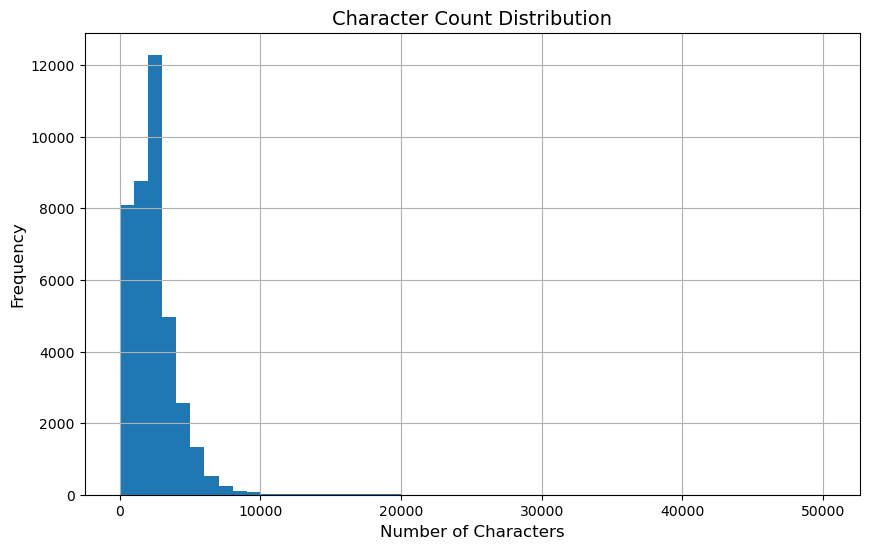

In [15]:
plt.figure(figsize=(10,6))

plt.hist(df["char_count"], bins=50)

plt.title("Character Count Distribution", fontsize=14)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True)

plt.show()

In [16]:
df["char_count"].max()

50109

## Histogram of word count

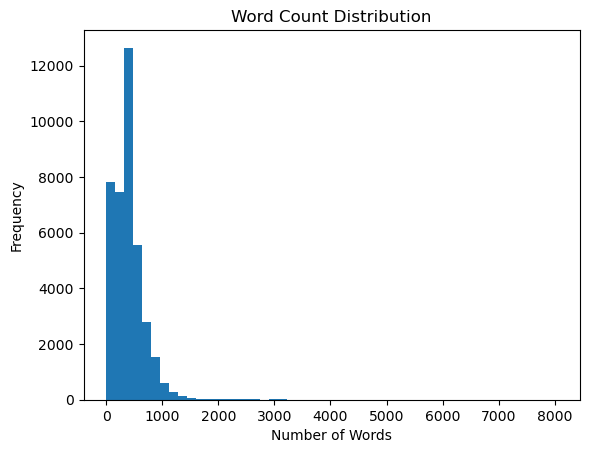

In [17]:
df["word_count"].plot(kind="hist", bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## Comparing Fake and Real News by Text Length

Here I compare the number of words in fake and real news articles to see if there is any visible difference.

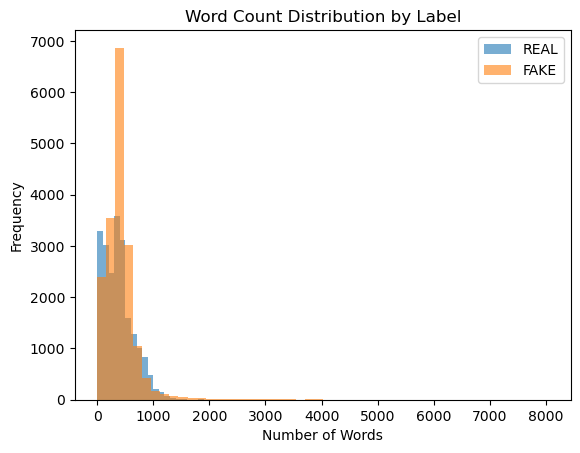

In [18]:
df[df["label"] == "REAL"]["word_count"].plot(kind="hist", bins=50, alpha=0.6, label="REAL")
df[df["label"] == "FAKE"]["word_count"].plot(kind="hist", bins=50, alpha=0.6, label="FAKE")

plt.title("Word Count Distribution by Label")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Average word count by label

In [19]:
df.groupby("label")["word_count"].mean()

label
FAKE    422.633637
REAL    388.014955
Name: word_count, dtype: float64

## Most Common Words

To get a first idea of the language used in the dataset, I look at the most common words in the cleaned text.

In [20]:
all_words = " ".join(df["content_clean"]).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)
common_words_df = pd.DataFrame(common_words, columns=["word", "count"])
common_words_df

,word,count
0,the,860872
1,to,473798
2,of,380569
3,a,354724
4,and,348465
5,in,305159
6,that,202630
7,on,172935
8,for,153418
9,s,143021


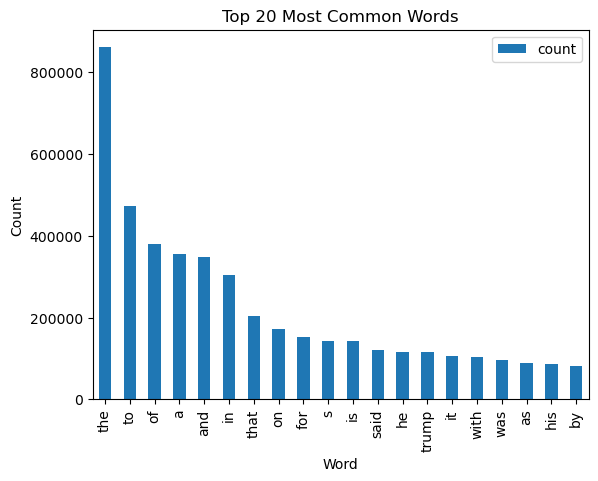

In [21]:
# Plot the most common words
common_words_df.plot(x="word", y="count", kind="bar")
plt.title("Top 20 Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.show()

## Most common words in REAL news only

In [22]:
real_words = " ".join(df[df["label"] == "REAL"]["content_clean"]).split()
real_word_counts = Counter(real_words)
real_common_words = real_word_counts.most_common(20)

real_common_words_df = pd.DataFrame(real_common_words, columns=["word", "count"])
real_common_words_df

,word,count
0,the,472733
1,to,249446
2,of,205349
3,a,194922
4,in,182314
5,and,179664
6,on,110027
7,said,97801
8,that,85395
9,for,81288


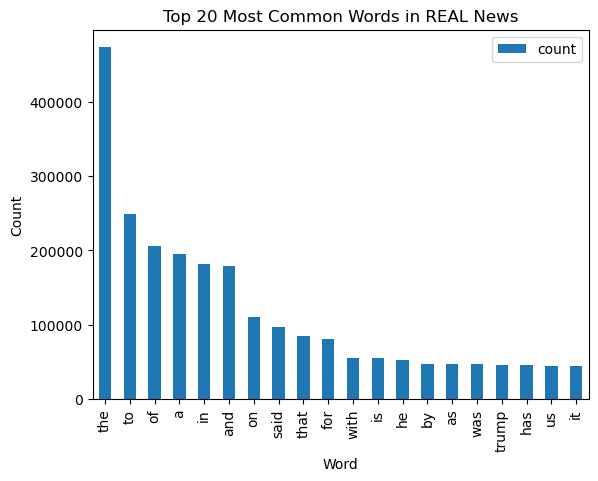

In [23]:
real_common_words_df.plot(x="word", y="count", kind="bar")
plt.title("Top 20 Most Common Words in REAL News")
plt.xlabel("Word")
plt.ylabel("Count")
plt.show()

## Most common words in Fake news only

In [24]:
fake_words = " ".join(df[df["label"] == "FAKE"]["content_clean"]).split()
fake_word_counts = Counter(fake_words)
fake_common_words = fake_word_counts.most_common(20)

fake_common_words_df = pd.DataFrame(fake_common_words, columns=["word", "count"])
fake_common_words_df

,word,count
0,the,388139
1,to,224352
2,of,175220
3,and,168801
4,a,159802
5,in,122845
6,that,117235
7,s,98912
8,is,87860
9,for,72130


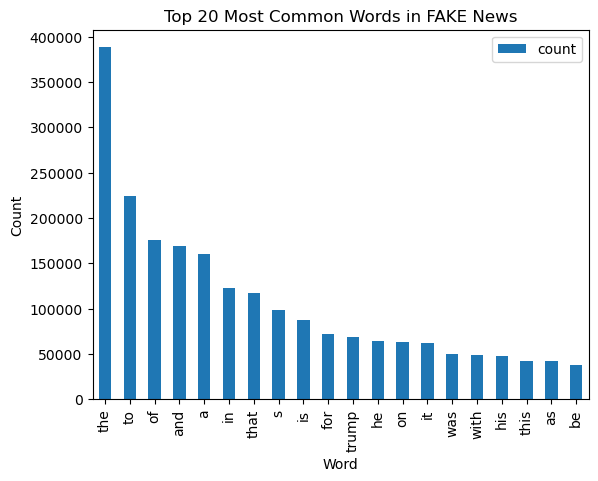

In [25]:
fake_common_words_df.plot(x="word", y="count", kind="bar")
plt.title("Top 20 Most Common Words in FAKE News")
plt.xlabel("Word")
plt.ylabel("Count")
plt.show()

## Check the form of the some Clean rows

In [26]:
df[df["label"] == "REAL"][["content_clean"]].head(3)

,content_clean
3,california ag pledges to defend birth control ...
5,as private lawyer trump high court pick was fr...
6,yemeni salafist imam killed in aden sources ad...


In [27]:
df[df["label"] == "FAKE"][["content_clean"]].head(3)

,content_clean
0,breaking gop chairman grassley has had enough ...
1,failed gop candidates remembered in hilarious ...
2,mike pence’s new dc neighbors are hilariously ...


## Main Observations

From this exploratory analysis, I noticed that:

- the dataset is relatively balanced between real and fake news
- Article lengths vary widely across the dataset, with the majority of articles concentrated at lower word counts and a long tail of      significantly longer articles.
- some words appear very frequently in both classes
- fake and real news may differ in writing style and word usage

This analysis helps prepare for the next step, where I will convert the text into numerical features and train a machine learning model.